In [14]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

from anngeno import AnnGeno
# pl.Config.set_tbl_rows(15)

In [15]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""score_pai3d""","""peru""","""PrimateAI-3D""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#28a745""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [16]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_MANE_CADD_251110.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# existing_annos = ['cadd_raw', 'gpn_score', 'gpn_star_llr_calibrated_mean']
# existing_annos = ['am_pathogenicity']

# Filter variant classes
variant_class = "non_coding"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

# min_range = -500
# max_range = +0

anno = (
    anno
    .filter(
        # Filter for non-coding variants
        # (pl.col('vep_cds') == False) &
        # (pl.col('mane_cds') == False) &
        # (pl.col('non_mane_cds') == False) &

        # Filter for coding variants
        ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True)) &
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &
        
        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)

anno

am_pathogenicity,tss,score_pai3d,region,strand,gpn_star_llr_calibrated_mean,delta_score,promoterai,cadd_raw,id,verphylop,pangolin_score,loftee_hc,absplice_dna_max,mamphylop,absplice2_max,dist_to_tss,gene_name,esmscoremissense,gpn_score,gene_length
f32,i64,f32,str,str,f32,f64,f32,f32,str,f32,f64,i8,f64,f32,f64,i64,str,f32,f32,i64
0.1245,158686715,0.84744,"""ENSG00000163554""","""-1""",-5.554446,0.0,null,3.672527,"""chr1:158647693:G:A""",4.855,0.01,0,0.001,1.456,0.000037,39022,"""SPTA1""",-7.817,-4.68,76013
null,158686715,null,"""ENSG00000163554""","""-1""",-2.336144,null,null,0.43585,"""chr1:158606719:A:T""",0.18,null,0,null,0.089,null,79996,"""SPTA1""",null,-2.9,76013
null,158686715,null,"""ENSG00000163554""","""-1""",-4.87806,null,null,3.540549,"""chr1:158606644:C:T""",1.38,null,0,null,2.88,null,80071,"""SPTA1""",null,-6.27,76013
0.4223,158686715,0.711197,"""ENSG00000163554""","""-1""",-6.39668,0.0,null,2.849353,"""chr1:158612895:C:G""",1.314,0.0,0,0.001,0.187,0.000056,73820,"""SPTA1""",-3.764,-6.91,76013
null,158686715,null,"""ENSG00000163554""","""-1""",-0.758234,null,null,4.309285,"""chr1:158606904:G:A""",2.113,null,0,null,4.452,null,79811,"""SPTA1""",null,-2.18,76013
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
null,127854658,null,"""ENSG00000106991""","""-1""",-2.038648,null,null,0.951121,"""chr9:127806979:C:T""",null,null,0,null,null,null,47679,"""ENG""",null,-2.72,39647
null,127854658,null,"""ENSG00000106991""","""-1""",-3.121241,null,null,0.076991,"""chr9:127809823:G:A""",null,null,0,null,null,null,44835,"""ENG""",null,-4.33,39647
null,127854658,null,"""ENSG00000106991""","""-1""",-2.296968,null,null,1.027075,"""chr9:127808638:C:T""",null,null,0,null,null,null,46020,"""ENG""",null,-3.57,39647


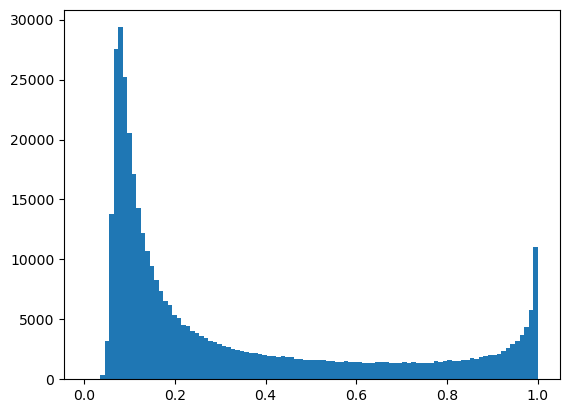

In [17]:
plt.hist(anno['am_pathogenicity'].drop_nulls(), bins=100)
plt.show()

In [ ]:
melted_anno = (
    anno
    .unpivot(
        index=["id", "region"],
        on=existing_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df,
        on="annotation",
        how="left"
    )

    .filter(
        # Remove null annotation scores
        (pl.col('annotation_score').is_not_null()) &

        # Filter based on category
        pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'missense'])
        # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation']))
    )

    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]).cast(pl.Float32),
        anno_score_count = pl.len().over(["region", "annotation"]).cast(pl.Int32)
    )
    .with_columns(
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count').round(4).cast(pl.Float32)
    )
    .drop(['anno_score_count', 'annotation_score_dircor'])
)

melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor_rank,annotation_score_dircor_ptile
str,str,str,f32,str,str,str,i8,f32,f32
"""chr1:158647693:G:A""","""ENSG00000163554""","""am_pathogenicity""",0.1245,"""missense""","""#feb72d""","""AlphaMissense""",1,786.5,0.380687
"""chr1:158612895:C:G""","""ENSG00000163554""","""am_pathogenicity""",0.4223,"""missense""","""#feb72d""","""AlphaMissense""",1,1704.0,0.824782
"""chr1:158618054:G:T""","""ENSG00000163554""","""am_pathogenicity""",0.1255,"""missense""","""#feb72d""","""AlphaMissense""",1,800.0,0.387222
"""chr1:158635989:C:T""","""ENSG00000163554""","""am_pathogenicity""",0.1623,"""missense""","""#feb72d""","""AlphaMissense""",1,1080.5,0.522991
"""chr1:158648513:T:C""","""ENSG00000163554""","""am_pathogenicity""",0.104,"""missense""","""#feb72d""","""AlphaMissense""",1,538.5,0.260649
…,…,…,…,…,…,…,…,…,…
"""chr10:116089804:C:A""","""ENSG00000151892""","""absplice2_max""",0.000241,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,240.5,0.448694
"""chr10:116065595:T:C""","""ENSG00000151892""","""absplice2_max""",0.000256,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,279.0,0.520522
"""chr10:116125244:G:A""","""ENSG00000151892""","""absplice2_max""",0.001201,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,459.0,0.856343


In [19]:
ptile_counts_df = (
    melted_anno
    .group_by(['annotation', 'annotation_score_dircor_ptile'])
    .agg(
        n_vars_at_ptile = pl.len()
    )
    .sort('annotation_score_dircor_ptile', descending=True)
    .with_columns(
        n_vars_above_ptile = pl.col('n_vars_at_ptile').cum_sum().over('annotation')
    )
)

melted_anno = melted_anno.join(ptile_counts_df, on=['annotation', 'annotation_score_dircor_ptile'], how='inner')
melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor_rank,annotation_score_dircor_ptile,n_vars_at_ptile,n_vars_above_ptile
str,str,str,f32,str,str,str,i8,f32,f32,u64,u64
"""chr1:158647693:G:A""","""ENSG00000163554""","""am_pathogenicity""",0.1245,"""missense""","""#feb72d""","""AlphaMissense""",1,786.5,0.380687,2,246690
"""chr1:158612895:C:G""","""ENSG00000163554""","""am_pathogenicity""",0.4223,"""missense""","""#feb72d""","""AlphaMissense""",1,1704.0,0.824782,1,70009
"""chr1:158618054:G:T""","""ENSG00000163554""","""am_pathogenicity""",0.1255,"""missense""","""#feb72d""","""AlphaMissense""",1,800.0,0.387222,3,244081
"""chr1:158635989:C:T""","""ENSG00000163554""","""am_pathogenicity""",0.1623,"""missense""","""#feb72d""","""AlphaMissense""",1,1080.5,0.522991,4,190066
"""chr1:158648513:T:C""","""ENSG00000163554""","""am_pathogenicity""",0.104,"""missense""","""#feb72d""","""AlphaMissense""",1,538.5,0.260649,2,294427
…,…,…,…,…,…,…,…,…,…,…,…
"""chr10:116089804:C:A""","""ENSG00000151892""","""absplice2_max""",0.000241,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,240.5,0.448694,8,345369
"""chr10:116065595:T:C""","""ENSG00000151892""","""absplice2_max""",0.000256,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,279.0,0.520522,9,304530
"""chr10:116125244:G:A""","""ENSG00000151892""","""absplice2_max""",0.001201,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,459.0,0.856343,1,93627


In [20]:
ct_df = melted_anno.group_by('annotation').agg(
    n_vars = pl.len(),
    max_ptile = pl.col('annotation_score_dircor_ptile').max(),
).sort('n_vars', descending=True)

assert ct_df['max_ptile'].min() == 1.0
ct_df

annotation,n_vars,max_ptile
str,u64,f32
"""cadd_raw""",758975,1.0
"""gpn_score""",758975,1.0
"""gpn_star_llr_calibrated_mean""",758975,1.0
"""verphylop""",758417,1.0
"""mamphylop""",758417,1.0
…,…,…
"""absplice_dna_max""",641406,1.0
"""delta_score""",635490,1.0
"""esmscoremissense""",432507,1.0


In [21]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [22]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
# gene_trait_df = gene_trait_df.filter(
#     pl.col('gene_name') == "LDLR",
#     pl.col('phenotype') == "ldl_direct_int",
# )
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


## Odds ratio computation

In [23]:
n_steps = 100
min_rank_cutoff = 1_000
max_rank_cutoff = 500_000
or_threshold_pheno = 0.99

cutoffs_list = np.geomspace(
# cutoffs_list = np.linspace(
    min_rank_cutoff, 
    max_rank_cutoff, 
    num=n_steps
).tolist()

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": cutoffs_list})

cutoffs_lazy.collect()

rank_cutoff
f64
1000.0
1064.785978
1133.769179
1207.221523
1285.43255
…
388974.123842
414174.192803
441006.872872


In [ ]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    .select(["annotation", "region", "gene_name", "phenotype", "n_vars_above_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "gene_name", "phenotype", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("n_vars_above_ptile") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("n_vars_above_ptile") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("n_vars_above_ptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("n_vars_above_ptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        # odds_ratio = ((pl.col("n_dis_above_cutoff") + 1) / (pl.col("n_notdis_above_cutoff")+1)) / (1 - or_threshold_pheno)
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff')

or_df.write_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_{or_threshold_pheno}_ranks_{min_rank_cutoff}_wgs_EUR_genebass1e6_maf1e3.parquet')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""absplice2_max""","""ENSG00000146830""","""GIGYF1""","""apolipoprotein_b_int""",1000.0,0,2,13,1063,0.0
"""cadd_raw""","""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_left_int""",1000.0,0,1,11,1010,0.0
"""am_pathogenicity""","""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",1000.0,0,0,5,357,NaN
"""gpn_star_llr_calibrated_mean""","""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",1000.0,0,1,7,513,0.0
"""delta_score""","""ENSG00000119403""","""PHF19""","""arm_predicted_mass_left_int""",1000.0,0,1,4,315,0.0
…,…,…,…,…,…,…,…,…,…
"""verphylop""","""ENSG00000146197""","""SCUBE3""","""whole_body_water_mass_int""",500000.0,3,423,2,202,0.716312
"""absplice_dna_max""","""ENSG00000159899""","""NPR2""","""whole_body_water_mass_int""",500000.0,12,529,1,61,1.383743
"""cadd_raw""","""ENSG00000119403""","""PHF19""","""whole_body_water_mass_int""",500000.0,1,222,0,108,inf


## Plotting

In [25]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
    )
    .with_columns(
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'rank_cutoff', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('rank_cutoff')
)

plt_df

unique percentile cutoffs: 100


annotation,rank_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
"""absplice_dna_max""",1000.0,795,0.0,2.66471,0.502618,3.649842,1.679579,"""#28a745""","""AbSplice (max)"""
"""esmscoremissense""",1000.0,816,0.0,1.869989,0.395731,2.645623,1.094356,"""#feb72d""","""ESM1v"""
"""score_pai3d""",1000.0,622,0.0,3.352179,0.558026,4.44591,2.258447,"""peru""","""PrimateAI-3D"""
"""gpn_score""",1000.0,782,0.0,1.867653,0.373823,2.600346,1.13496,"""pink""","""GPN-MSA"""
"""am_pathogenicity""",1000.0,776,0.0,4.488549,0.631441,5.726173,3.250924,"""#feb72d""","""AlphaMissense"""
…,…,…,…,…,…,…,…,…,…
"""mamphylop""",500000.0,1052,1.351302,1.908119,0.052871,2.011746,1.804492,"""#942c80""","""Mammalian PhyloP"""
"""absplice2_max""",500000.0,803,1.055569,1.329518,0.035846,1.399777,1.259259,"""#28a745""","""AbSplice2 (max)"""
"""absplice_dna_max""",500000.0,733,1.037663,1.339337,0.043197,1.424003,1.254672,"""#28a745""","""AbSplice (max)"""


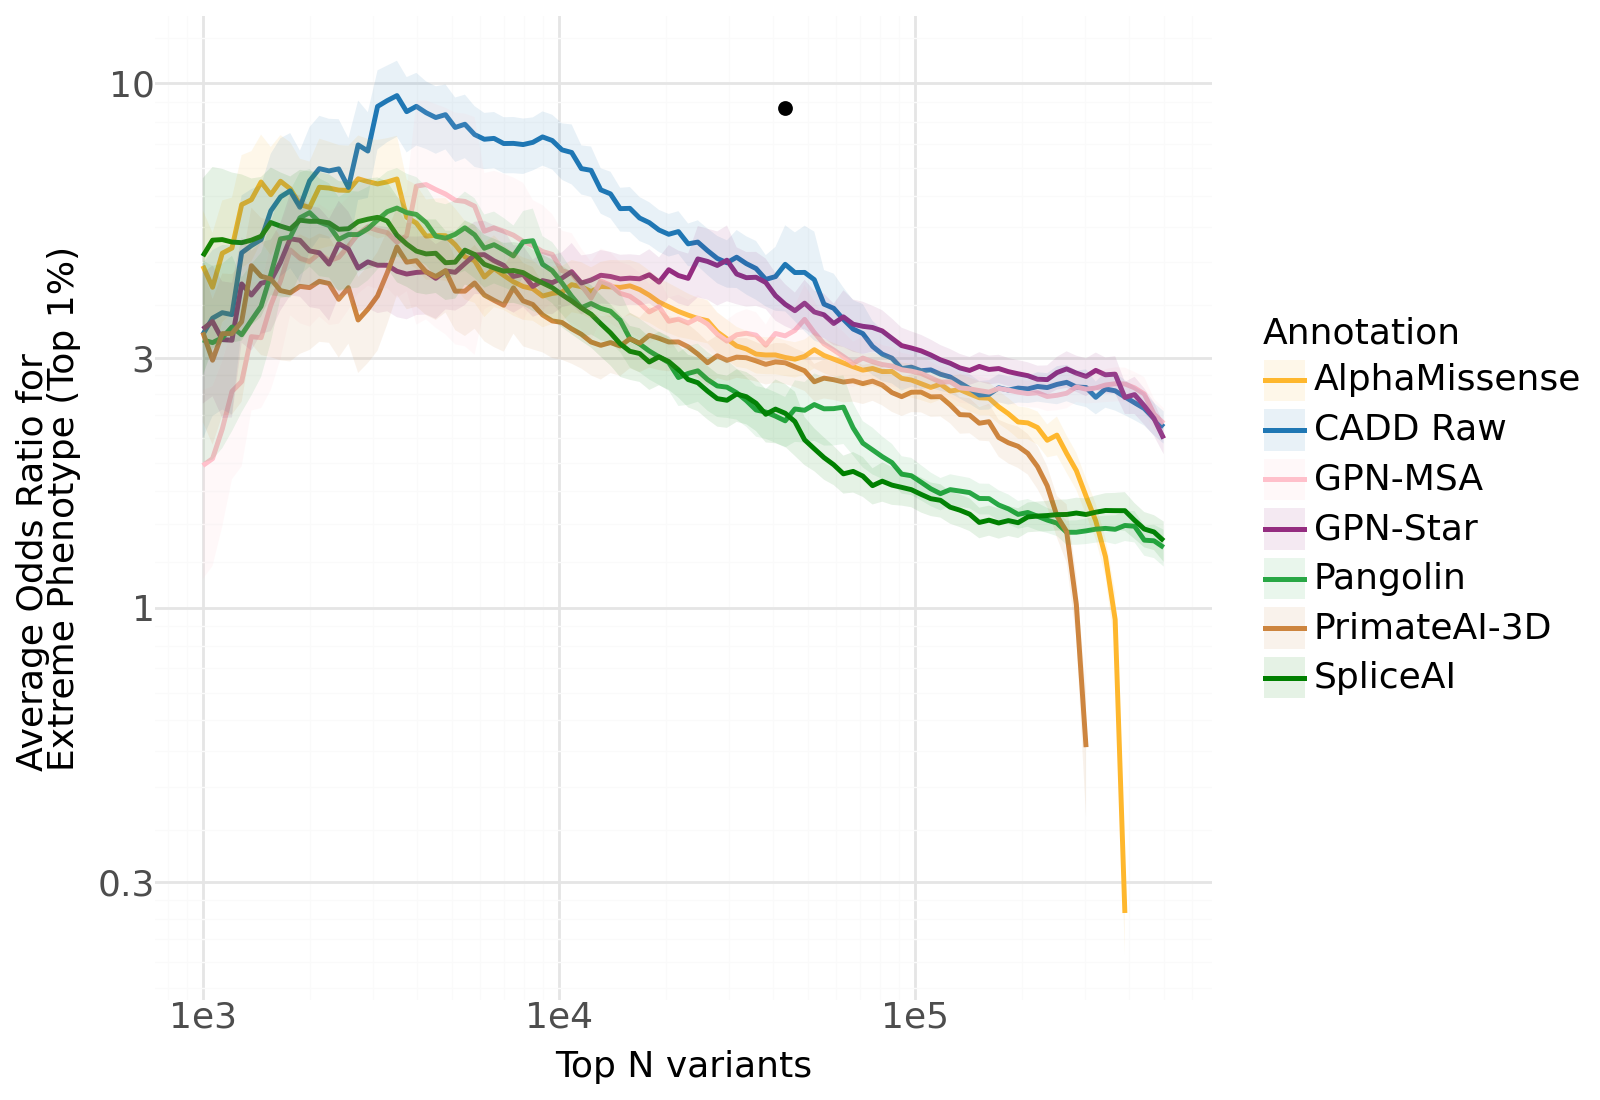

In [26]:
color_dict = dict(zip(plt_df['label'], plt_df['color']))

# am_lof_df = pl.DataFrame({
#     'annotation': ['loftee_coding', 'am_0.8_coding'],
#     'n_vars': [21519, 56609],
#     'mean_or': [6.874422, 2.323273],
#     'median_or': [3.04127, 1.770242],
# })

am_lof_df = pl.DataFrame({
    'annotation': ['loftee_coding', 'am_0.8_coding'],
    'n_vars': [43179, 57191],
    'mean_or': [8.963194, 3.196688],
    'median_or': [3.724961, 1.955789],
})

(
    ggplot(
        # plt_df,
        plt_df.filter(pl.col('annotation').is_in(['cadd_raw', 'gpn_star_llr_calibrated_mean', 'gpn_score', 'pangolin_score', 'delta_score', 'am_pathogenicity', 'score_pai3d'])),
        # plt_df.filter(pl.col('annotation').is_in(['cadd_raw', 'gpn_star_llr_calibrated_mean', 'pangolin_score', 'delta_score'])),
        aes(x='rank_cutoff', y='avg_odds_ratio')
    )
    + geom_line(aes(color='label'), size=1)
    + geom_point(am_lof_df.filter(pl.col('annotation')=='loftee_coding'), aes(x='n_vars', y='mean_or'), color='black', size=2)
    # + geom_point(am_lof_df.filter(pl.col('annotation')=='am_0.8_coding'), aes(x='n_vars', y='mean_or'), color='#AA4344', size=2)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        y="Average Odds Ratio for\nExtreme Phenotype (Top 1%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_log10()
    + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)